In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

In [15]:
# Organize data into train, valid, test dirs
os.chdir('C:/Users/yuvar/Deep learning/xray_dataset')
if os.path.isdir('train/fractured') is False:
    os.makedirs('train/healthy')
    os.makedirs('train/fractured')
    os.makedirs('valid/healthy')
    os.makedirs('valid/fractured')
    os.makedirs('test/healthy')
    os.makedirs('test/fractured')


for jpgfile in random.sample(glob.glob('healthy*.jpg'), 750):
        shutil.move(jpgfile, 'train/healthy')      
for jpgfile in random.sample(glob.glob('fractured*.jpg'), 750):
        shutil.move(jpgfile, 'train/fractured')      
for jpgfile in random.sample(glob.glob('healthy*.jpg'), 250):
        shutil.move(jpgfile, 'valid/healthy')      
for jpgfile in random.sample(glob.glob('fractured*.jpg'), 250):
        shutil.move(jpgfile, 'valid/fractured')      
for jpgfile in random.sample(glob.glob('healthy*.jpg'), 50):
        shutil.move(jpgfile, 'test/healthy')      
for jpgfile in random.sample(glob.glob('fractured*.jpg'), 50):
        shutil.move(jpgfile, 'test/fractured')      


os.chdir('../../')

ValueError: Sample larger than population or is negative

In [16]:
train_path = "C:/Users/yuvar/Deep learning/xray_dataset/train"
valid_path = "C:/Users/yuvar/Deep learning/xray_dataset/valid"
test_path = "C:/Users/yuvar/Deep learning/xray_dataset/test"

In [17]:
train_batches = ImageDataGenerator(preprocessing_function = tf.keras.applications.vgg19.preprocess_input) \
.flow_from_directory(train_path, target_size = (224, 224), classes = ['fractured', 'healthy'], batch_size = 40)

valid_batches = ImageDataGenerator(preprocessing_function = tf.keras.applications.vgg19.preprocess_input) \
.flow_from_directory(valid_path, target_size = (224, 224), classes = ['fractured', 'healthy'], batch_size = 40)

test_batches = ImageDataGenerator(preprocessing_function = tf.keras.applications.vgg19.preprocess_input) \
.flow_from_directory(test_path, target_size = (224, 224), classes = ['fractured', 'healthy'], batch_size = 40)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 80 images belonging to 2 classes.


In [18]:
imgs, labels = next(train_batches)

In [19]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 10, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip( images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

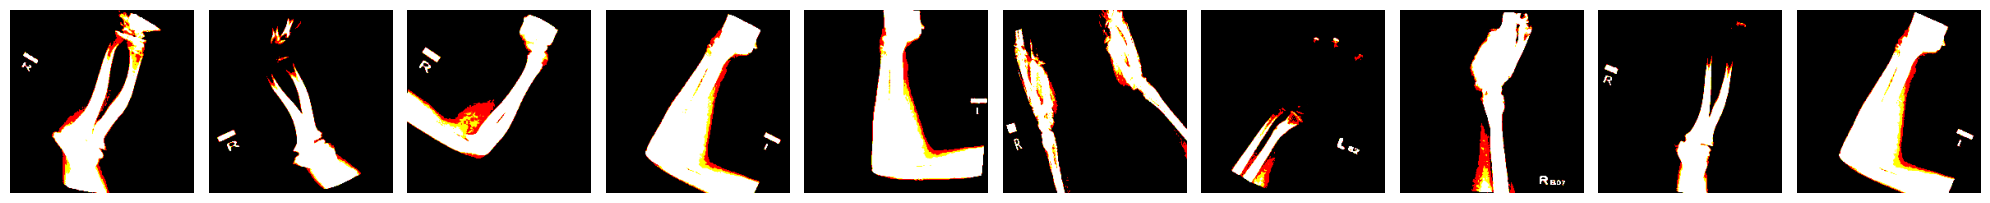

[[1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [20]:
plotImages(imgs)
print(labels)

In [21]:
model = Sequential([
    Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu', padding = 'same', input_shape = (224, 224, 3)),
    MaxPool2D(pool_size = (2, 2), strides = 2),
    Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu', padding = 'same'),
    MaxPool2D(pool_size = (2, 2), strides = 2),
    Flatten(),
    Dense(units = 2, activation = 'softmax')
    
])

In [22]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 200704)            0         
                                                                 
 dense (Dense)               (None, 2)                 4

In [23]:
model.compile(optimizer = Adam(learning_rate = 0.0001), loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [24]:
model.fit(x = train_batches, validation_data = valid_batches, epochs = 10, verbose = 2)

Epoch 1/10
38/38 - 36s - loss: 24.1824 - accuracy: 0.6133 - val_loss: 2.7176 - val_accuracy: 0.7860 - 36s/epoch - 953ms/step
Epoch 2/10
38/38 - 32s - loss: 1.2572 - accuracy: 0.8467 - val_loss: 0.8209 - val_accuracy: 0.9020 - 32s/epoch - 837ms/step
Epoch 3/10
38/38 - 30s - loss: 0.1746 - accuracy: 0.9633 - val_loss: 0.7188 - val_accuracy: 0.9060 - 30s/epoch - 779ms/step
Epoch 4/10
38/38 - 31s - loss: 0.0424 - accuracy: 0.9847 - val_loss: 0.3804 - val_accuracy: 0.9360 - 31s/epoch - 814ms/step
Epoch 5/10
38/38 - 31s - loss: 0.0033 - accuracy: 1.0000 - val_loss: 0.3754 - val_accuracy: 0.9420 - 31s/epoch - 829ms/step
Epoch 6/10
38/38 - 31s - loss: 0.0013 - accuracy: 1.0000 - val_loss: 0.3583 - val_accuracy: 0.9500 - 31s/epoch - 812ms/step
Epoch 7/10
38/38 - 31s - loss: 8.5020e-04 - accuracy: 1.0000 - val_loss: 0.3439 - val_accuracy: 0.9460 - 31s/epoch - 813ms/step
Epoch 8/10
38/38 - 31s - loss: 7.0846e-04 - accuracy: 1.0000 - val_loss: 0.3348 - val_accuracy: 0.9460 - 31s/epoch - 806ms/step

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

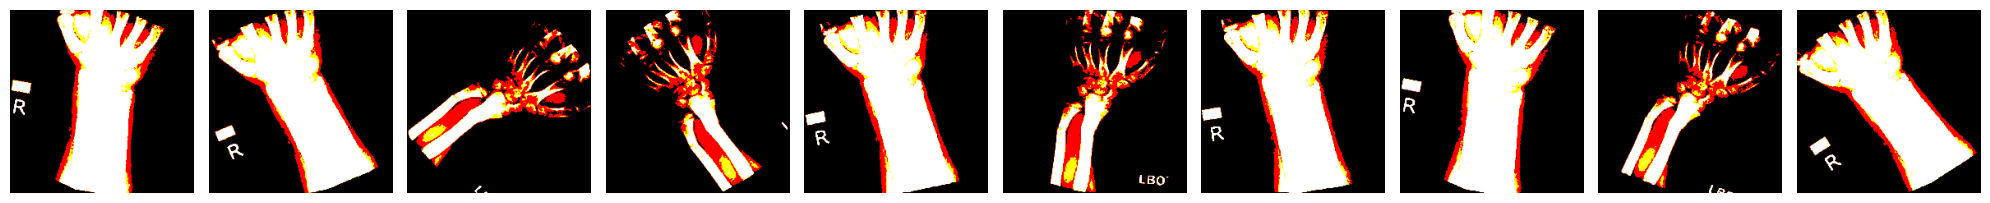

[[0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


In [25]:
test_imgs, test_labels = next(test_batches)
plotImages(test_imgs)
print(test_labels)

In [26]:
test_batches.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [27]:
predictions = model.predict(x=test_batches, verbose = 0)

In [28]:
np.round(predictions)

array([[0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.

In [29]:
cm = confusion_matrix(y_true = test_batches.classes, y_pred = np.argmax(predictions, axis = -1))

In [30]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Reds):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


In [31]:
test_batches.class_indices

{'fractured': 0, 'healthy': 1}

Confusion matrix, without normalization
[[17 23]
 [24 16]]


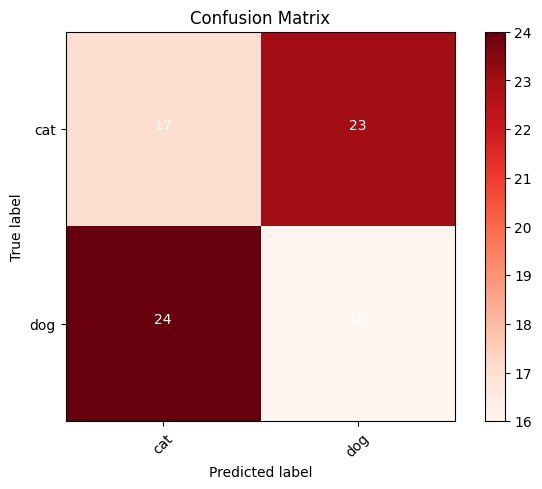

In [32]:
cm_plot_labels = ['cat','dog']
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix')

In [33]:
vgg19_model = tf.keras.applications.vgg19.VGG19()

In [34]:
vgg19_model.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [35]:
model = Sequential()
for layer in vgg19_model.layers[:-1]:
    model.add(layer)

In [36]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0         
                                                                 
 block3_conv1 (Conv2D)       (None, 56, 56, 256)      

In [37]:
for layer in model.layers:
    layer.trainable = False

In [38]:
model.add(Dense(units = 2, activation = 'softmax'))

In [39]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0         
                                                                 
 block3_conv1 (Conv2D)       (None, 56, 56, 256)      

In [40]:
model.compile(optimizer = Adam(learning_rate = 0.0001), loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [41]:
model.fit(x = train_batches, validation_data = valid_batches, epochs = 10, verbose = 2)

Epoch 1/10
38/38 - 613s - loss: 0.7719 - accuracy: 0.5520 - val_loss: 0.6102 - val_accuracy: 0.6460 - 613s/epoch - 16s/step
Epoch 2/10
38/38 - 1012s - loss: 0.5067 - accuracy: 0.7420 - val_loss: 0.4648 - val_accuracy: 0.7980 - 1012s/epoch - 27s/step
Epoch 3/10
38/38 - 961s - loss: 0.4006 - accuracy: 0.8207 - val_loss: 0.3975 - val_accuracy: 0.8380 - 961s/epoch - 25s/step
Epoch 4/10
38/38 - 1134s - loss: 0.3429 - accuracy: 0.8693 - val_loss: 0.3574 - val_accuracy: 0.8580 - 1134s/epoch - 30s/step
Epoch 5/10
38/38 - 880s - loss: 0.3018 - accuracy: 0.8940 - val_loss: 0.3255 - val_accuracy: 0.8680 - 880s/epoch - 23s/step
Epoch 6/10
38/38 - 868s - loss: 0.2751 - accuracy: 0.9080 - val_loss: 0.3060 - val_accuracy: 0.8740 - 868s/epoch - 23s/step
Epoch 7/10
38/38 - 832s - loss: 0.2500 - accuracy: 0.9140 - val_loss: 0.2851 - val_accuracy: 0.8900 - 832s/epoch - 22s/step
Epoch 8/10
38/38 - 649s - loss: 0.2287 - accuracy: 0.9307 - val_loss: 0.2648 - val_accuracy: 0.9100 - 649s/epoch - 17s/step
Epoc

In [42]:
predictions = model.predict(x = test_batches, verbose = 0)

In [43]:
test_batches.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [49]:
cm = confusion_matrix(y_true = test_batches.classes, y_pred = np.argmax(predictions, axis = 1))

In [50]:
test_batches.class_indices

{'fractured': 0, 'healthy': 1}

Confusion matrix, without normalization
[[32  8]
 [33  7]]


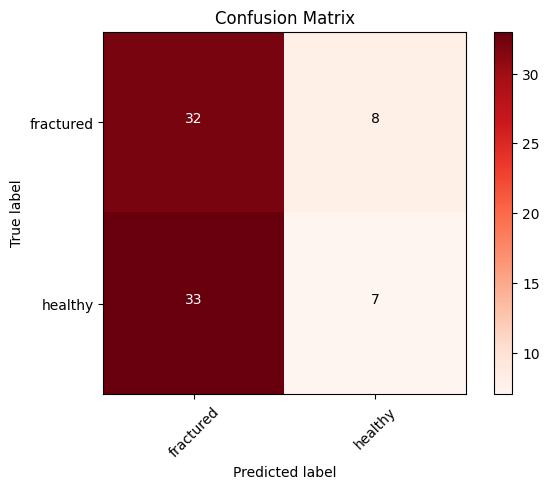

In [51]:
cm_plot_labels = ['fractured','healthy']
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix')